# LR01 - Linear Regression using concrete.csv
Name : Sreelakshmi V
Reg No.: KH.EN.P2MCA25158

## Dataset Description
The dataset used is concrete.csv, which contains 1030 samples and 9 columns.

Input features (independent variables):
- Cement (component 1)
- Blast Furnace Slag (component 2)
- Fly Ash (component 3)
- Water (component 4)
- Superplasticizer (component 5)
- Coarse Aggregate (component 6)
- Fine Aggregate (component 7)
- Age (day)

Target variable (dependent variable):
- strength (Concrete compressive strength)

In [9]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [10]:
df = pd.read_csv('concrete.csv')
print('Shape:', df.shape)
df.head()

Shape: (1030, 9)


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   strength                                         

In [12]:
print('Missing values by column:')
df.isna().sum()

Missing values by column:


Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
strength                                                 0
dtype: int64

In [13]:
target_col = 'strength'
if target_col not in df.columns:
    target_col = df.columns[-1]

df = df.fillna(df.median(numeric_only=True))

X = df.drop(target_col, axis=1)
y = df[target_col]

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train shape:', train_X.shape)
print('Test shape:', test_X.shape)

Train shape: (824, 8)
Test shape: (206, 8)


In [14]:
lin_reg = LinearRegression()
lin_reg.fit(train_X, train_y)

lin_train_pred = lin_reg.predict(train_X)
lin_test_pred = lin_reg.predict(test_X)

print('Linear Regression Train R2:', r2_score(train_y, lin_train_pred))
print('Linear Regression Test R2 :', r2_score(test_y, lin_test_pred))
print('Linear Regression Test RMSE:', np.sqrt(mean_squared_error(test_y, lin_test_pred)))
print('Linear Regression Test MAE :', mean_absolute_error(test_y, lin_test_pred))

Linear Regression Train R2: 0.6105238047649741
Linear Regression Test R2 : 0.6275531792314848
Linear Regression Test RMSE: 9.796475901624362
Linear Regression Test MAE : 7.745559243921435


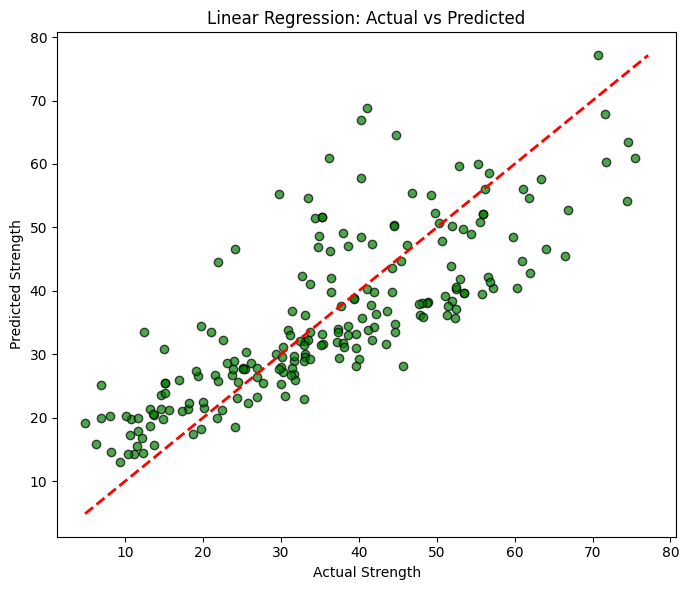

In [15]:
plt.figure(figsize=(7, 6))
plt.scatter(test_y, lin_test_pred, c='green', edgecolors='black', alpha=0.7)
line_min = min(test_y.min(), lin_test_pred.min())
line_max = max(test_y.max(), lin_test_pred.max())
plt.plot([line_min, line_max], [line_min, line_max], 'r--', linewidth=2)
plt.xlabel('Actual Strength')
plt.ylabel('Predicted Strength')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()

In [16]:
predictions_df = test_X.copy()
predictions_df['Actual'] = test_y.values
predictions_df['Predicted'] = lin_test_pred
predictions_df['Error'] = predictions_df['Actual'] - predictions_df['Predicted']

predictions_df.to_csv('lr01_predictions.csv', index=False)
print('Predictions saved to lr01_predictions.csv')
predictions_df.head()

Predictions saved to lr01_predictions.csv


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),Actual,Predicted,Error
31,266.0,114.0,0.0,228.0,0.0,932.0,670.0,365,52.91,59.658042,-6.748042
109,362.6,189.0,0.0,164.9,11.6,944.7,755.8,7,55.90,52.041211,3.858789
136,389.9,189.0,0.0,145.9,22.0,944.7,755.8,28,74.50,63.535133,10.964867
88,362.6,189.0,0.0,164.9,11.6,944.7,755.8,3,35.30,51.575457,-16.275457
918,145.0,0.0,179.0,202.0,8.0,824.0,869.0,28,10.54,17.220017,-6.680017


In [17]:
lasso_reg = Lasso(alpha=0.1, max_iter=10000)
lasso_reg.fit(train_X, train_y)

ridge_reg = Ridge(alpha=1.0)
ridge_reg.fit(train_X, train_y)

lasso_test_pred = lasso_reg.predict(test_X)
ridge_test_pred = ridge_reg.predict(test_X)

In [18]:
comparison_df = pd.DataFrame({
    'Model': ['LinearRegression', 'Lasso (L1)', 'Ridge (L2)'],
    'Train_R2': [
        lin_reg.score(train_X, train_y),
        lasso_reg.score(train_X, train_y),
        ridge_reg.score(train_X, train_y)
    ],
    'Test_R2': [
        lin_reg.score(test_X, test_y),
        lasso_reg.score(test_X, test_y),
        ridge_reg.score(test_X, test_y)
    ],
    'Test_RMSE': [
        np.sqrt(mean_squared_error(test_y, lin_test_pred)),
        np.sqrt(mean_squared_error(test_y, lasso_test_pred)),
        np.sqrt(mean_squared_error(test_y, ridge_test_pred))
    ]
})
comparison_df

,Model,Train_R2,Test_R2,Test_RMSE
0,LinearRegression,0.610524,0.627553,9.796476
1,Lasso (L1),0.610522,0.627576,9.796181
2,Ridge (L2),0.610524,0.627553,9.796474


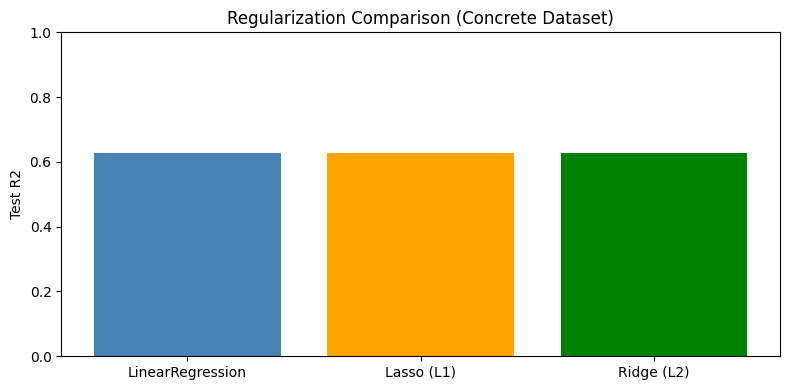

In [19]:
plt.figure(figsize=(8, 4))
plt.bar(comparison_df['Model'], comparison_df['Test_R2'], color=['steelblue', 'orange', 'green'])
plt.title('Regularization Comparison (Concrete Dataset)')
plt.ylabel('Test R2')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()